In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Titanic dataset
df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (891, 15)


In [12]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [13]:
print("Statistical Description:")
display(df.describe())

Statistical Description:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
# Save the raw loaded dataset
df.to_csv("titanic.csv", index=False)

print("Saved titanic.csv successfully.")

Saved titanic.csv successfully.


In [24]:
# Missing Values Percentage
missing_values = df.isnull().sum()
print(missing_values)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [25]:
# Columns with missing values and their percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing value percentage:")
missing_percentage = missing_percentage[missing_percentage > 0]
missing_percentage


Missing value percentage:


,0
age,19.865320
embarked,0.224467
deck,77.216611
embark_town,0.224467


In [26]:
# Making a copy so that the original loaded dataset is preserved
cleaned_df = df.copy()

# 1. Drop rows where embarked is missing
cleaned_df = cleaned_df.dropna(subset=["embarked"])

# 2. Drop rows where embark_town is missing
cleaned_df = cleaned_df.dropna(subset=["embark_town"])

# 3. Drop the deck column because 77.22% of its values are missing
cleaned_df = cleaned_df.drop(columns=["deck"])

# 4. Fill missing age values using the median age
age_median = cleaned_df["age"].median()
cleaned_df["age"] = cleaned_df["age"].fillna(age_median)

print("Cleaning completed.")
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", cleaned_df.shape)

print("\nMissing values after cleaning:")
print(cleaned_df.isnull().sum())

Cleaning completed.
Original dataset shape: (891, 15)
Cleaned dataset shape: (889, 14)

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [29]:
# Checking missing values
new_missing_percentage = (cleaned_df.isnull().sum() / len(df)) * 100
print("\nMissing value percentage:")
new_missing_percentage = new_missing_percentage[new_missing_percentage > 0]
new_missing_percentage


Missing value percentage:


,0


##Histogram and Box plots for both age and fare

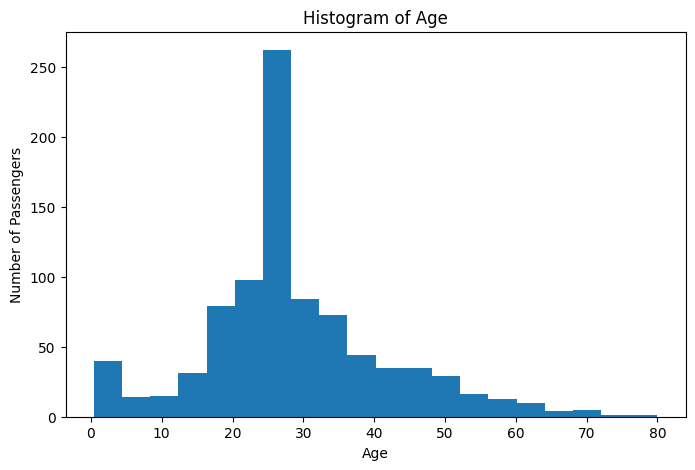

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(cleaned_df["age"], bins=20)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Histogram of Age")

plt.show()

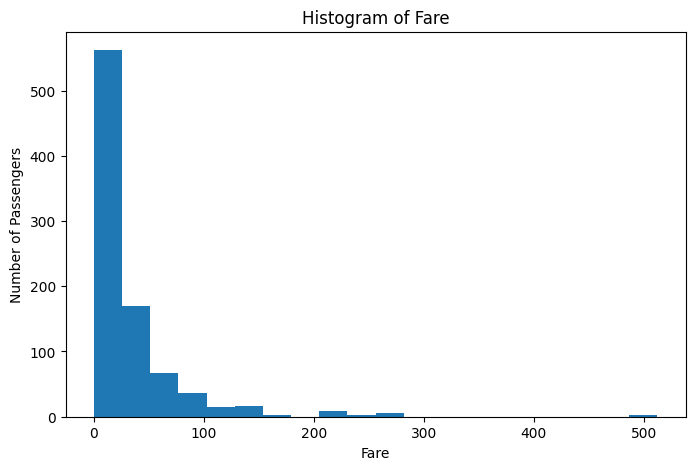

In [35]:
plt.figure(figsize=(8, 5))

plt.hist(cleaned_df["fare"], bins=20)

plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.title("Histogram of Fare")

plt.show()

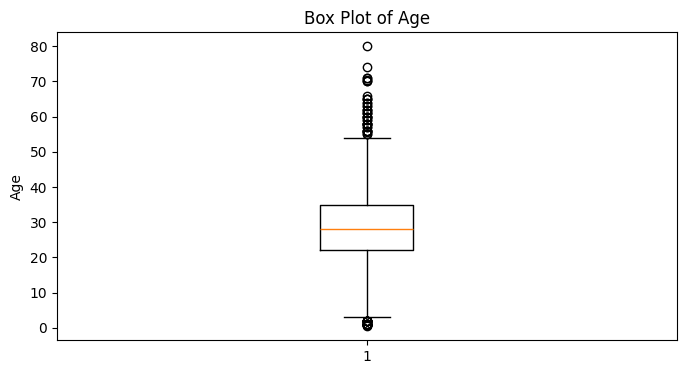

In [33]:
plt.figure(figsize=(8, 4))

plt.boxplot(cleaned_df["age"])

plt.ylabel("Age")
plt.title("Box Plot of Age")

plt.show()

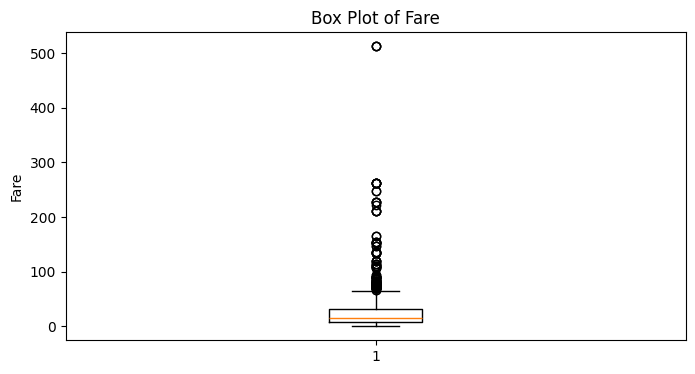

In [34]:
plt.figure(figsize=(8, 4))

plt.boxplot(cleaned_df["fare"])

plt.ylabel("Fare")
plt.title("Box Plot of Fare")

plt.show()

##IQR Calculation

In [40]:
# For AGE
Q1_age = cleaned_df["age"].quantile(0.25)
Q3_age = cleaned_df["age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = cleaned_df[
    (cleaned_df["age"] < lower_age) |
    (cleaned_df["age"] > upper_age)
]

print("Age Q1:", Q1_age)
print("Age Q3:", Q3_age)
print("Age IQR:", IQR_age)
print("Age lower limit:", lower_age)
print("Age upper limit:", upper_age)
print("Number of age outliers:", len(age_outliers))

Age Q1: 22.0
Age Q3: 35.0
Age IQR: 13.0
Age lower limit: 2.5
Age upper limit: 54.5
Number of age outliers: 65


In [39]:
# For FARE
Q1_fare = cleaned_df["fare"].quantile(0.25)
Q3_fare = cleaned_df["fare"].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = cleaned_df[
    (cleaned_df["fare"] < lower_fare) |
    (cleaned_df["fare"] > upper_fare)
]

print("Fare Q1:", Q1_fare)
print("Fare Q3:", Q3_fare)
print("Fare IQR:", IQR_fare)
print("Fare lower limit:", lower_fare)
print("Fare upper limit:", upper_fare)
print("Number of fare outliers:", len(fare_outliers))

Fare Q1: 7.8958
Fare Q3: 31.0
Fare IQR: 23.1042
Fare lower limit: -26.7605
Fare upper limit: 65.6563
Number of fare outliers: 114


In [41]:
fare_mean = cleaned_df["fare"].mean()
fare_median = cleaned_df["fare"].median()
fare_mode = cleaned_df["fare"].mode()[0]

print("Fare mean:", fare_mean)
print("Fare median:", fare_median)
print("Fare mode:", fare_mode)

Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: 8.05


###Interpretation

The fare distribution is strongly right-skewed because the mean fare (32.10) is considerably higher than the median fare (14.45), while the mode is 8.05. This indicates that most passengers paid relatively low fares, while a smaller number of passengers paid substantially higher fares, pulling the mean upward.

Using the IQR method, 114 fare outliers and 65 age outliers were identified. These observations were not removed because being an outlier does not necessarily mean that the observation is incorrect or invalid. In particular, higher fares can represent legitimate differences in passenger class, ticket pricing, or travel arrangements.

##Bivariate Analysis

In [42]:
survival_by_sex = cleaned_df.groupby("sex")["survived"].mean() * 100

print("Survival rate by sex:")
print(survival_by_sex)

Survival rate by sex:
sex
female    74.038462
male      18.890815
Name: survived, dtype: float64


In [43]:
survival_by_class = cleaned_df.groupby("pclass")["survived"].mean() * 100

print("Survival rate by passenger class:")
print(survival_by_class)

Survival rate by passenger class:
pclass
1    62.616822
2    47.282609
3    24.236253
Name: survived, dtype: float64


In [44]:
survival_by_sex_class = (
    cleaned_df
    .groupby(["sex", "pclass"])["survived"]
    .mean()
    * 100
)

print("Survival rate by sex and passenger class:")
print(survival_by_sex_class)

Survival rate by sex and passenger class:
sex     pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64


In [47]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = cleaned_df[correlation_columns].corr()

print("Correlation matrix:")
display(correlation_matrix)

Correlation matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


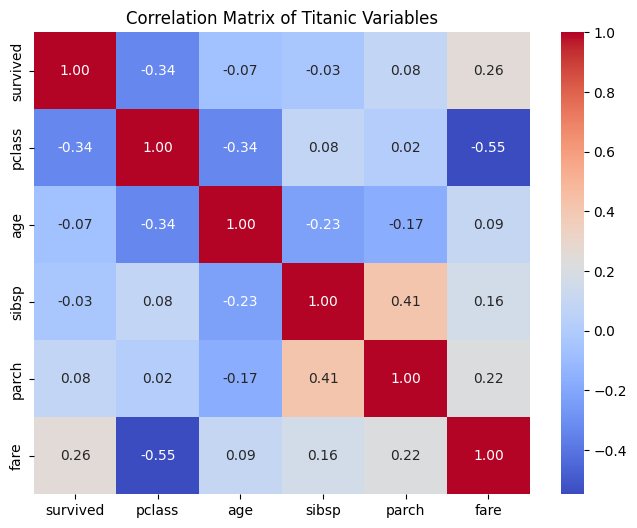

In [46]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Titanic Variables")
plt.show()

###Interpretation

The survival rate differs substantially by sex. Female passengers had a survival rate of 74.04%, compared with 18.89% for male passengers.

Survival also varied by passenger class. First-class passengers had a survival rate of 62.62%, followed by second-class passengers at 47.28% and third-class passengers at 24.24%.

When sex and passenger class were considered together, female passengers had higher survival rates within every class. Female survival rates were 96.74% in first class, 92.11% in second class, and 50.00% in third class. Male survival rates were substantially lower across all three classes.

From the correlation matrix, the two strongest correlations by absolute magnitude were between pclass and fare (-0.548) and between pclass and age (-0.337). The negative pclass-fare correlation indicates that higher numerical class values are associated with lower fares. The negative pclass-age correlation indicates a moderate tendency for higher numerical passenger classes to be associated with younger passengers in this dataset. Correlation does not imply causation.

##Survival by Sex and Passenger Class

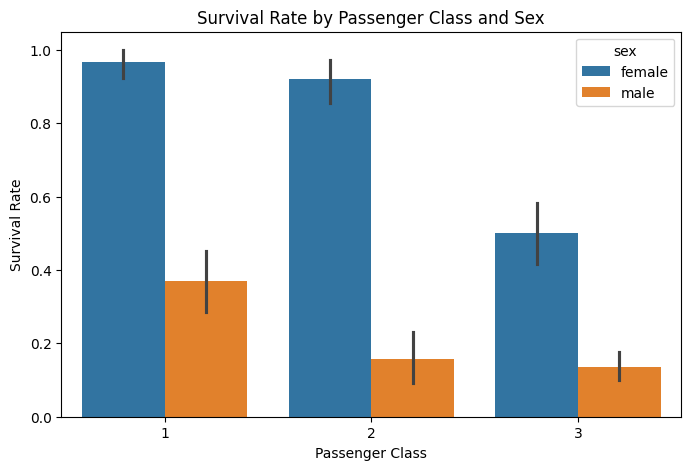

In [48]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cleaned_df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Passenger Class and Sex")

plt.show()

### This Chart says

The chart shows that female passengers had higher survival rates than male passengers across all passenger classes. First- and second-class female passengers had particularly high survival rates, while male passengers had much lower survival rates. Third-class passengers generally had lower survival rates, especially males.

##Survival by Sex and Age Group

In [49]:
# Creating age groups
cleaned_df["age_group"] = pd.cut(
    cleaned_df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

print("Age groups created:")
print(cleaned_df["age_group"].value_counts().sort_index())

Age groups created:
age_group
Child           69
Teenager        70
Young Adult    535
Adult          194
Senior          21
Name: count, dtype: int64


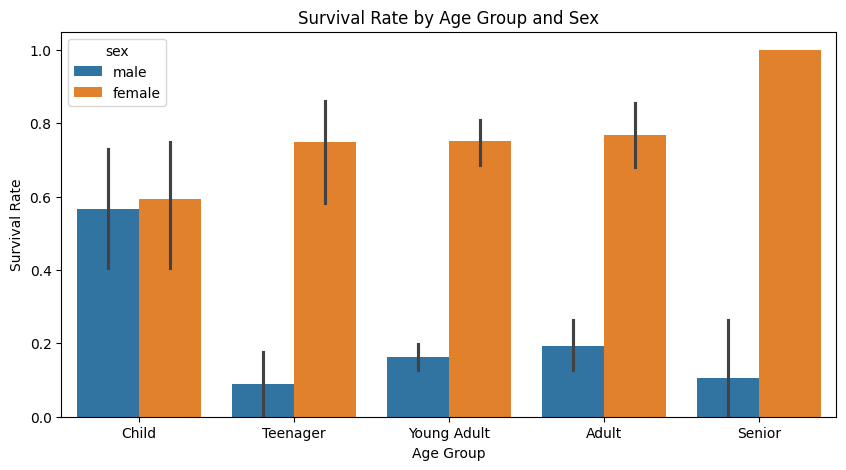

In [50]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=cleaned_df,
    x="age_group",
    y="survived",
    hue="sex"
)

plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Age Group and Sex")

plt.show()

### This Chart says

Survival rates vary across age groups and between sexes. Female passengers generally show higher survival rates than male passengers within the same age group. The differences across age groups suggest that age also had a relationship with survival, although the effect varies depending on sex.

##Fare Distribution by Passenger Class and Survival

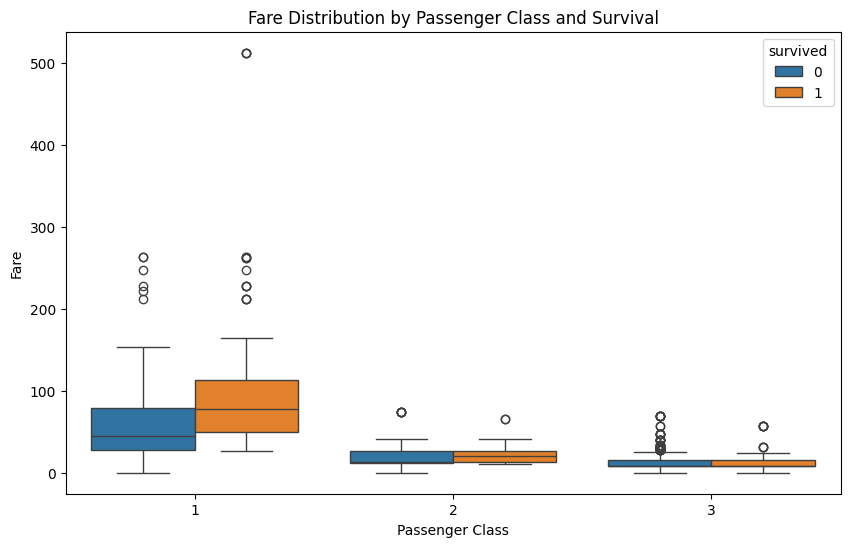

In [51]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cleaned_df,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.title("Fare Distribution by Passenger Class and Survival")

plt.show()

###Fare, Passenger Class and Survival

Fare values differ substantially between passenger classes, with first-class passengers generally paying higher fares than second- and third-class passengers. The distribution also differs between survivors and non-survivors within some classes. This visualization supports the earlier correlation between passenger class and fare and shows how fare levels varied across passenger groups.

##Age Distribution by Sex and Survival

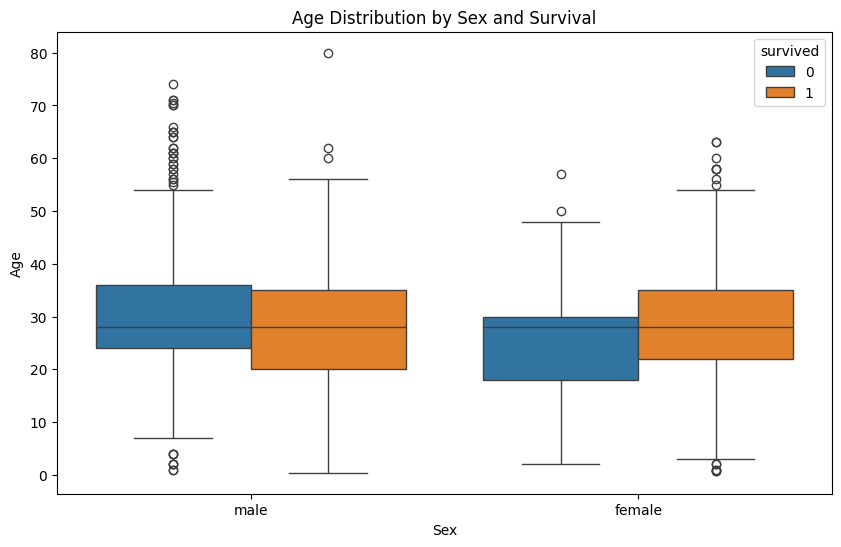

In [52]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cleaned_df,
    x="sex",
    y="age",
    hue="survived"
)

plt.xlabel("Sex")
plt.ylabel("Age")
plt.title("Age Distribution by Sex and Survival")

plt.show()

###Age, Sex and Survival

The age distributions of survivors and non-survivors differ between males and females. The chart also shows the spread of ages within each group and highlights that survival was influenced by multiple passenger characteristics rather than a single variable.

##StandardScaler

In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
scaler = StandardScaler()

standardized_data = scaler.fit_transform(
    cleaned_df[["age", "fare"]]
)

standardized_df = pd.DataFrame(
    standardized_data,
    columns=["age_standardized", "fare_standardized"]
)

display(standardized_df.head())

,age_standardized,fare_standardized
0,-0.563674,-0.500240
1,0.669217,0.788947
2,-0.255451,-0.486650
3,0.438050,0.422861
4,0.438050,-0.484133


In [55]:
print("Mean after standardization:")
print(standardized_df.mean())

print("\nStandard deviation after standardization:")
print(standardized_df.std())

Mean after standardization:
age_standardized     2.717486e-16
fare_standardized    1.398706e-16
dtype: float64

Standard deviation after standardization:
age_standardized     1.000563
fare_standardized    1.000563
dtype: float64


In [56]:
print("Mean:")
print(standardized_df.mean())

print("\nPopulation standard deviation:")
print(standardized_df.std(ddof=0))

Mean:
age_standardized     2.717486e-16
fare_standardized    1.398706e-16
dtype: float64

Population standard deviation:
age_standardized     1.0
fare_standardized    1.0
dtype: float64


### Standardization Check

Age and fare were standardized using `StandardScaler`. After standardization, both variables have a mean close to 0 and a population standard deviation close to 1. This confirms that standardization changed the scale of the variables without removing their underlying observations or changing the relative structure of the data.

In [62]:
import os
import shutil

repo_path = "/content/Zepto-Capstone-Project"
analytics_path = repo_path + "/analytics"

# Create analytics folder
os.makedirs(analytics_path, exist_ok=True)

# Create the required raw CSV from the original dataset
df.to_csv(
    analytics_path + "/titanic.csv",
    index=False
)

print("Analytics folder created.")
print("titanic.csv created.")
print("CSV shape:", df.shape)
print("CSV exists:", os.path.exists(analytics_path + "/titanic.csv"))

Analytics folder created.
titanic.csv created.
CSV shape: (891, 15)
CSV exists: True
